##### Importing the necessarry libraries #####

In [301]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
#from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score,KFold,StratifiedKFold,LeaveOneOut 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier


In [195]:
df = pd.read_csv("used_cars.csv") #Importing the dataset

# take a look at the dataset
df.head()

,Unnamed: 0,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,3,2,164,audi,gas,std,four,sedan,fwd,front,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,4,2,164,audi,gas,std,four,sedan,4wd,front,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [197]:
df.tail()

,Unnamed: 0,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
200,200,-1,95,volvo,gas,std,four,sedan,rwd,front,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,202,-1,95,volvo,gas,std,four,sedan,rwd,front,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470
204,204,-1,95,volvo,gas,turbo,four,sedan,rwd,front,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625


#### DATA CLEANING ####

In [199]:
df = df.drop(columns=['Unnamed: 0']) #dropping redundant column
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [201]:
df1=df.replace('?',np.NaN) #replacing '?' with 'Nan'

In [203]:
df=df1.dropna(subset=["price"], axis=0) #dropping rows that have missing price data
df.head(50)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.00,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.00,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.00,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.00,115,5500,18,22,17450
5,2,NaN,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.50,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.50,110,5500,19,25,17710
7,1,NaN,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.50,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.30,140,5500,17,20,23875
10,2,192,bmw,gas,std,two,sedan,rwd,front,101.2,...,108,mpfi,3.50,2.80,8.80,101,5800,23,29,16430


In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  164 non-null    object 
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       199 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non-null

In [207]:
df.isnull().sum() #calculating the number of missing data values in the dataset

symboling             0
normalized-losses    37
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 0
dtype: int64

#### DATA WRANGLING ####

In [ ]:
#this section involves filling in the missing data with their appropriate replacement depending on the data type

In [209]:
avg_norm_loss = df["normalized-losses"].astype("float").mean(axis=0)
print("Average of normalized-losses:", avg_norm_loss)
df["normalized-losses"].replace(np.nan, avg_norm_loss, inplace=True)

Average of normalized-losses: 122.0


C:\Users\User\AppData\Local\Temp\ipykernel_16368\2858829755.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["normalized-losses"].replace(np.nan, avg_norm_loss, inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_16368\2858829755.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["normalized-losses"].replace(np.nan, avg_norm_los

In [211]:
avg_bore=df['bore'].astype('float').mean(axis=0)
print("Average of bore:", avg_bore)
df["bore"].replace(np.nan, avg_bore, inplace=True)

Average of bore: 3.330710659898477


C:\Users\User\AppData\Local\Temp\ipykernel_16368\2583803075.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["bore"].replace(np.nan, avg_bore, inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_16368\2583803075.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["bore"].replace(np.nan, avg_bore, inplace=True)


In [213]:
avg_stroke = df["stroke"].astype("float").mean(axis = 0)
print("Average of stroke:", avg_stroke)

df["stroke"].replace(np.nan, avg_stroke, inplace = True)

Average of stroke: 3.256903553299492


C:\Users\User\AppData\Local\Temp\ipykernel_16368\2426728443.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["stroke"].replace(np.nan, avg_stroke, inplace = True)
C:\Users\User\AppData\Local\Temp\ipykernel_16368\2426728443.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["stroke"].replace(np.nan, avg_stroke, inplace = True)


In [215]:
avg_horsepower = df['horsepower'].astype('float').mean(axis=0)
print("Average horsepower:", avg_horsepower)
df['horsepower'].replace(np.nan, avg_horsepower, inplace=True)

Average horsepower: 103.39698492462311


C:\Users\User\AppData\Local\Temp\ipykernel_16368\425933634.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].replace(np.nan, avg_horsepower, inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_16368\425933634.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['horsepower'].replace(np.nan, avg_horsepower, inplace=Tru

In [217]:
avg_peakrpm=df['peak-rpm'].astype('float').mean(axis=0)
print("Average peak rpm:", avg_peakrpm)
df['peak-rpm'].replace(np.nan, avg_peakrpm, inplace=True)

Average peak rpm: 5117.587939698493


C:\Users\User\AppData\Local\Temp\ipykernel_16368\2906647747.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['peak-rpm'].replace(np.nan, avg_peakrpm, inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_16368\2906647747.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['peak-rpm'].replace(np.nan, avg_peakrpm, inplace=True)


In [219]:
df['num-of-doors'].value_counts().idxmax() #checking the median of the column, 'num-of-doors'

'four'

In [221]:
df["num-of-doors"].replace(np.nan, "four", inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_16368\2789465289.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["num-of-doors"].replace(np.nan, "four", inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_16368\2789465289.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["num-of-doors"].replace(np.nan, "four", inplace=True)


In [223]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


#### DATA TYPES ####

In [225]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    object 
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       201 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non-null

In [227]:
df.dtypes

symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object

In [ ]:
#Chnaging the data values to their appropriate data types

In [229]:
df[["bore", "stroke"]] = df[["bore", "stroke"]].astype("float")
df[["normalized-losses"]] = df[["normalized-losses"]].astype("int")
df[["price"]] = df[["price"]].astype("float")
df[["peak-rpm"]] = df[["peak-rpm"]].astype("float")
df[["horsepower"]] = df[["horsepower"]].astype("int")
df[['num-of-cylinders']] = df[['num-of-cylinders']].astype(str)
df[['num-of-doors']] = df[['num-of-doors']].astype(str)

C:\Users\User\AppData\Local\Temp\ipykernel_16368\572124680.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[["bore", "stroke"]] = df[["bore", "stroke"]].astype("float")
C:\Users\User\AppData\Local\Temp\ipykernel_16368\572124680.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[["normalized-losses"]] = df[["normalized-losses"]].astype("int")
C:\Users\User\AppData\Local\Temp\ipykernel_16368\572124680.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

In [231]:
df.dtypes

symboling              int64
normalized-losses      int32
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int32
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object

In [233]:
# Convertin mpg to L/100km  (235 divided by mpg)
df['city-L/100km'] = 235/df["city-mpg"]
df['highway-L/100km'] = 235/df["highway-mpg"]

# checking transformed data 
df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_16368\905347727.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['city-L/100km'] = 235/df["city-mpg"]
C:\Users\User\AppData\Local\Temp\ipykernel_16368\905347727.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['highway-L/100km'] = 235/df["highway-mpg"]


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,highway-L/100km
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000.0,21,27,13495.0,11.190476,8.703704
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000.0,21,27,16500.0,11.190476,8.703704
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,2.68,3.47,9.0,154,5000.0,19,26,16500.0,12.368421,9.038462
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,3.19,3.40,10.0,102,5500.0,24,30,13950.0,9.791667,7.833333
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,3.19,3.40,8.0,115,5500.0,18,22,17450.0,13.055556,10.681818


In [263]:
categorical_data = df.select_dtypes(include=['object', 'category']) #assigning categorical variables to 'categorical_data'
categorical_data

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system
0,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,audi,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,audi,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...
200,volvo,gas,std,four,sedan,rwd,front,ohc,four,mpfi
201,volvo,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
202,volvo,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
203,volvo,diesel,turbo,four,sedan,rwd,front,ohc,six,idi


In [265]:
ordinal_categorical_data = ['num-of-doors', 'num-of-cylinders'] #assigning ordijnal categorical data to a variable for label encoding
non_ordinal_categorical_data = ['make', 'fuel-type', 'aspiration', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'fuel-system'] #assigning non ordninal categorical data to a variable for one hot encoding

#### Label Encoding ####

In [267]:
door_mapping = {'two': 2, 'four': 4}
cylinder_mapping = {'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12}
# Applying mappings
categorical_data['num-of-doors'] = categorical_data['num-of-doors'].map(door_mapping)
categorical_data['num-of-cylinders'] = categorical_data['num-of-cylinders'].map(cylinder_mapping)
categorical_data

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system
0,alfa-romero,gas,std,2,convertible,rwd,front,dohc,4,mpfi
1,alfa-romero,gas,std,2,convertible,rwd,front,dohc,4,mpfi
2,alfa-romero,gas,std,2,hatchback,rwd,front,ohcv,6,mpfi
3,audi,gas,std,4,sedan,fwd,front,ohc,4,mpfi
4,audi,gas,std,4,sedan,4wd,front,ohc,5,mpfi
...,...,...,...,...,...,...,...,...,...,...
200,volvo,gas,std,4,sedan,rwd,front,ohc,4,mpfi
201,volvo,gas,turbo,4,sedan,rwd,front,ohc,4,mpfi
202,volvo,gas,std,4,sedan,rwd,front,ohcv,6,mpfi
203,volvo,diesel,turbo,4,sedan,rwd,front,ohc,6,idi


#### One Hot Encoding ####

In [277]:
categorical_data = pd.get_dummies(categorical_data, columns=non_ordinal_categorical_data, drop_first=True)  # Drop first to avoid dummy variable trap
categorical_data = dummy.astype(int)

# Step 4: Output
categorical_data

,num-of-doors,num-of-cylinders,make_audi,make_bmw,make_chevrolet,make_dodge,make_honda,make_isuzu,make_jaguar,make_mazda,...,engine-type_ohcf,engine-type_ohcv,engine-type_rotor,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,2,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,2,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,2,6,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
3,4,4,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,4,5,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,4,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
201,4,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
202,4,6,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
203,4,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [119]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,highway-L/100km
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,3.330711,3.256904,10.164279,103.393035,5117.587940,25.179104,8.044957,13207.129353,9.944145,30.686567
std,1.254802,31.99625,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,0.268072,0.316048,4.004965,37.365623,478.113178,6.423220,1.840739,7947.066342,2.534599,6.815150
min,-2.000000,65.00000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,4.351852,5118.000000,4.795918,16.000000
25%,0.000000,101.00000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,6.911765,7775.000000,7.833333,25.000000
50%,1.000000,122.00000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5117.587940,24.000000,7.833333,10295.000000,9.791667,30.000000
75%,2.000000,137.00000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,9.400000,16500.000000,12.368421,34.000000
max,3.000000,256.00000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,14.687500,45400.000000,18.076923,54.000000


### Data Exploration ###

##### Scatter PLot to visualize the distribution between Engine Size and Price

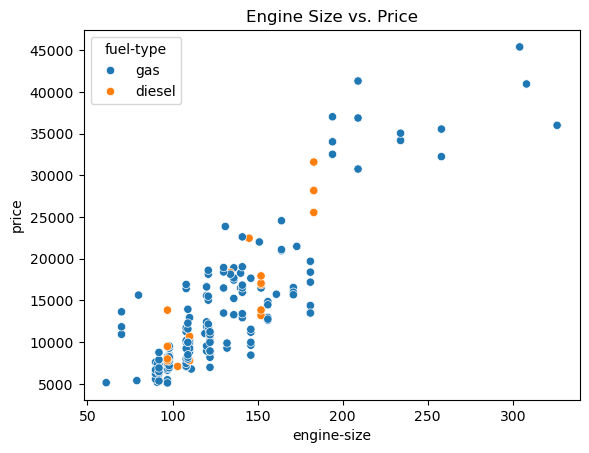

In [121]:
sns.scatterplot(data=df, x='engine-size', y='price', hue='fuel-type')
plt.title('Engine Size vs. Price')
plt.show()

##### A histohgram to show the distribution of price, engine size and horsepower

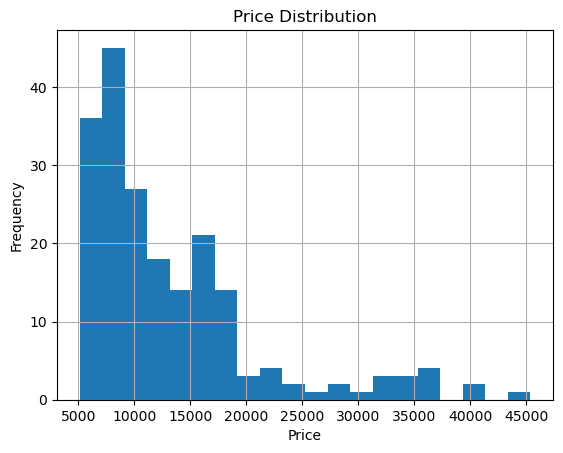

In [123]:
df['price'].hist(bins=20)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


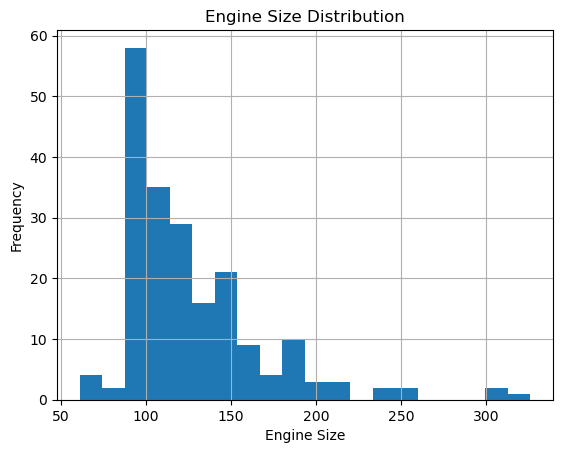

In [125]:
df['engine-size'].hist(bins=20)
plt.title('Engine Size Distribution')
plt.xlabel('Engine Size')
plt.ylabel('Frequency')
plt.show()

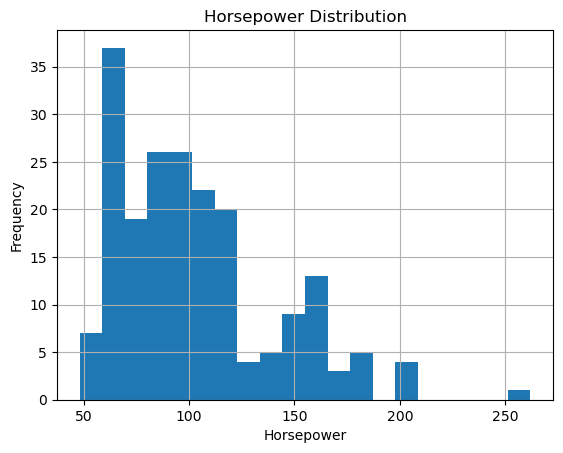

In [127]:
df['horsepower'].hist(bins=20)
plt.title('Horsepower Distribution')
plt.xlabel('Horsepower')
plt.ylabel('Frequency')
plt.show()

In [133]:
numerical_data = df.select_dtypes(include=['number']) #selecting the nurical data types
numerical_data

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,highway-L/100km
0,3,122,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000.0,21,8.703704,13495.0,11.190476,27.0
1,3,122,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000.0,21,8.703704,16500.0,11.190476,27.0
2,1,122,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000.0,19,9.038462,16500.0,12.368421,26.0
3,2,164,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500.0,24,7.833333,13950.0,9.791667,30.0
4,2,164,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500.0,18,10.681818,17450.0,13.055556,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,109.1,188.8,68.9,55.5,2952,141,3.78,3.15,9.5,114,5400.0,23,8.392857,16845.0,10.217391,28.0
201,-1,95,109.1,188.8,68.8,55.5,3049,141,3.78,3.15,8.7,160,5300.0,19,9.400000,19045.0,12.368421,25.0
202,-1,95,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,8.8,134,5500.0,18,10.217391,21485.0,13.055556,23.0
203,-1,95,109.1,188.8,68.9,55.5,3217,145,3.01,3.40,23.0,106,4800.0,26,8.703704,22470.0,9.038462,27.0


##### The correlation matrix is plotted to visualize the correlation between variables and which variable have a stonger relationship for analysis

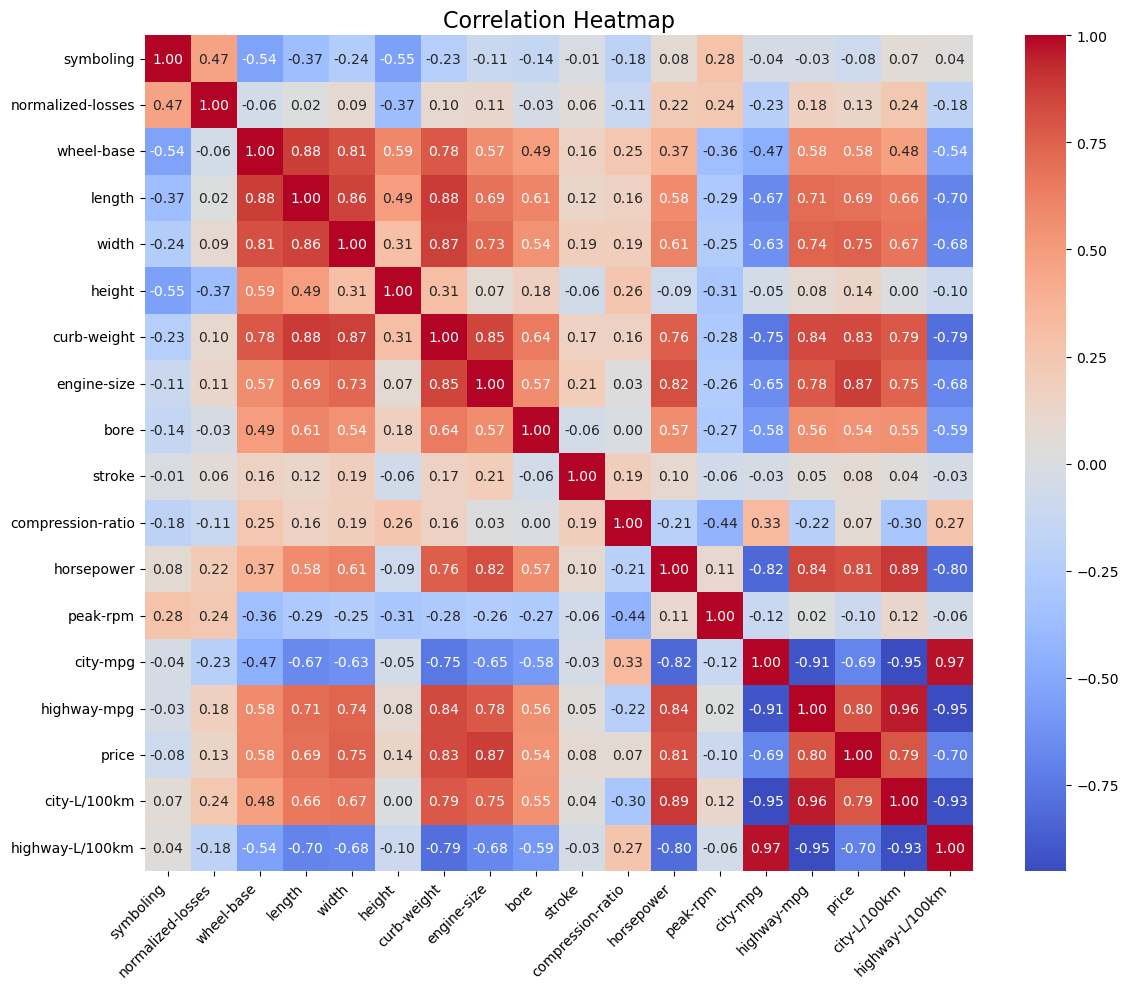

In [137]:
correlation_matrix = numerical_data.corr()
plt.figure(figsize=(12, 10))  # Adjust the figure size
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
plt.yticks(rotation=0)              # Keep y-axis labels horizontal
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()  # Adjust spacing to prevent cutoff
plt.show()

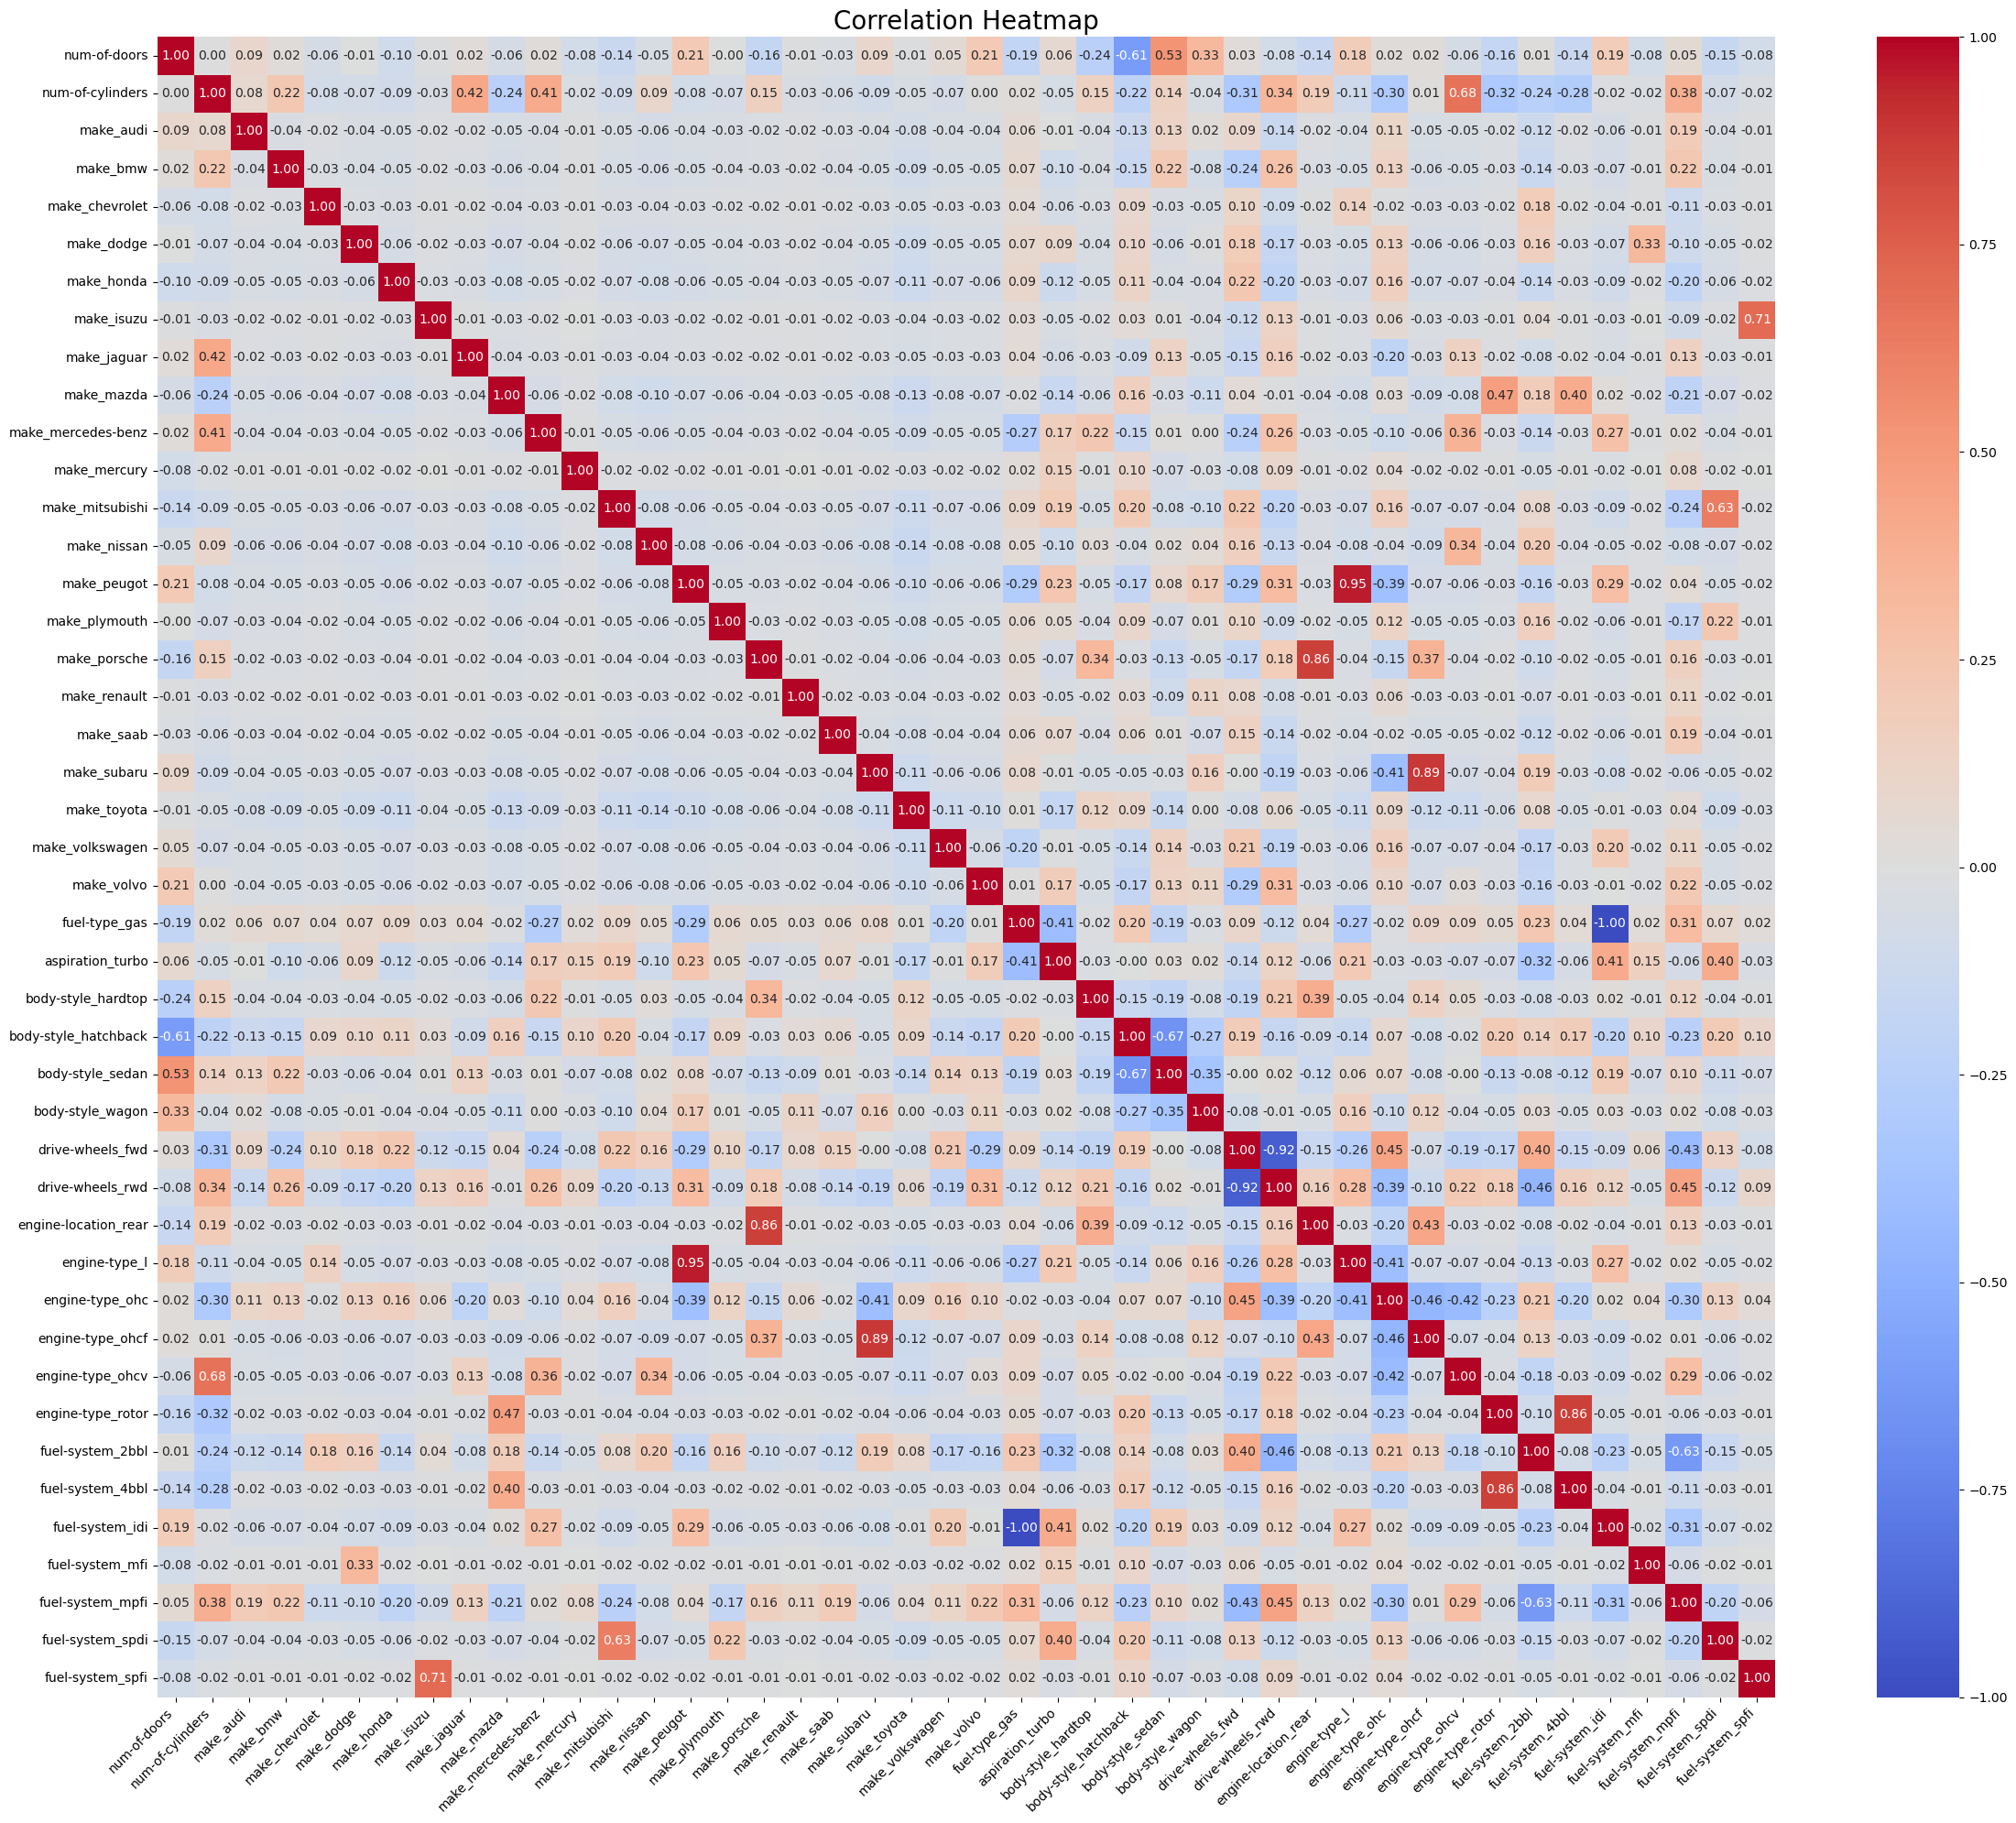

In [283]:
correlation_matrix = categorical_data.corr()
plt.figure(figsize=(24, 20))  # Adjust the figure size
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
plt.yticks(rotation=0)              # Keep y-axis labels horizontal
plt.title('Correlation Heatmap', fontsize=20)
plt.tight_layout()  # Adjust spacing to prevent cutoff
plt.show()

In [ ]:
#dropping the non encoded categorical data from the original dataframe and adding it to the numerical data

In [285]:
drop_columns = ordinal_categorical_data + non_ordinal_categorical_data
df2=df.drop(columns=drop_columns)
df2=pd.concat([df2,categorical_data],axis=1)
df2

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,engine-type_ohcf,engine-type_ohcv,engine-type_rotor,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,3,122,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0,0,0,0,0,0,0,1,0,0
1,3,122,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0,0,0,0,0,0,0,1,0,0
2,1,122,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,0,1,0,0,0,0,0,1,0,0
3,2,164,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,0,0,0,0,0,0,0,1,0,0
4,2,164,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,109.1,188.8,68.9,55.5,2952,141,3.78,3.15,...,0,0,0,0,0,0,0,1,0,0
201,-1,95,109.1,188.8,68.8,55.5,3049,141,3.78,3.15,...,0,0,0,0,0,0,0,1,0,0
202,-1,95,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,...,0,1,0,0,0,0,0,1,0,0
203,-1,95,109.1,188.8,68.9,55.5,3217,145,3.01,3.40,...,0,0,0,0,0,1,0,0,0,0


#### Scaling The Data ####

In [299]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df2)
scaled_df = pd.DataFrame(scaled_data, columns=df2.columns, index=df.index)
scaled_df

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,engine-type_ohcf,engine-type_ohcv,engine-type_rotor,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,1.725050,0.000000,-1.685107,-0.439409,-0.853460,-2.034081,-0.014858,0.075389,0.520894,-1.829927,...,-0.283981,-0.262962,-0.142494,-0.683486,-0.123091,-0.332411,-0.070711,1.088477,-0.216506,-0.070711
1,1.725050,0.000000,-1.685107,-0.439409,-0.853460,-2.034081,-0.014858,0.075389,0.520894,-1.829927,...,-0.283981,-0.262962,-0.142494,-0.683486,-0.123091,-0.332411,-0.070711,1.088477,-0.216506,-0.070711
2,0.127193,0.000000,-0.710103,-0.244152,-0.185597,-0.559713,0.518080,0.606234,-2.433435,0.675938,...,-0.283981,3.802833,-0.142494,-0.683486,-0.123091,-0.332411,-0.070711,1.088477,-0.216506,-0.070711
3,0.926121,1.315931,0.165748,0.195176,0.148335,0.218425,-0.423766,-0.431327,-0.526210,0.453899,...,-0.283981,-0.262962,-0.142494,-0.683486,-0.123091,-0.332411,-0.070711,1.088477,-0.216506,-0.070711
4,0.926121,1.315931,0.099646,0.195176,0.243744,0.218425,0.520017,0.220165,-0.526210,0.453899,...,-0.283981,-0.262962,-0.142494,-0.683486,-0.123091,-0.332411,-0.070711,1.088477,-0.216506,-0.070711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1.470664,-0.845956,1.702619,1.187733,1.436357,0.709881,0.768075,0.340812,1.680188,-0.339096,...,-0.283981,-0.262962,-0.142494,-0.683486,-0.123091,-0.332411,-0.070711,1.088477,-0.216506,-0.070711
201,-1.470664,-0.845956,1.702619,1.187733,1.388653,0.709881,0.956057,0.340812,1.680188,-0.339096,...,-0.283981,-0.262962,-0.142494,-0.683486,-0.123091,-0.332411,-0.070711,1.088477,-0.216506,-0.070711
202,-1.470664,-0.845956,1.702619,1.187733,1.436357,0.709881,0.884353,1.112950,0.932257,-1.227251,...,-0.283981,3.802833,-0.142494,-0.683486,-0.123091,-0.332411,-0.070711,1.088477,-0.216506,-0.070711
203,-1.470664,-0.845956,1.702619,1.187733,1.436357,0.709881,1.281633,0.437329,-1.199348,0.453899,...,-0.283981,-0.262962,-0.142494,-0.683486,-0.123091,3.008322,-0.070711,-0.918715,-0.216506,-0.070711


#### Regression Model ####

In [371]:
#X = df2[['engine-size', 'curb-weight', 'horsepower']]  # Features
X = scaled_df[['engine-size', 'curb-weight', 'horsepower']]  # Features

y = scaled_df['price']                                     # Target

# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [373]:
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# The coefficients
print ('Coefficients: ', model.coef_)
print ('Intercept: ',model.intercept_)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Coefficients:  [0.41161993 0.28154611 0.1600967 ]
Intercept:  -0.04295404600437333
Mean Squared Error: 0.44828973353476964
R-squared: 0.7697424448553761


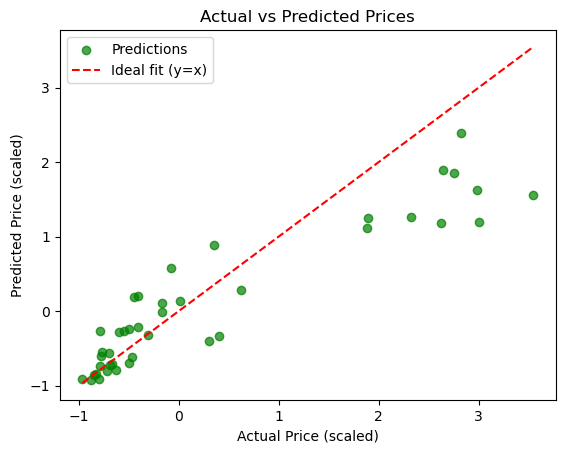

In [377]:
plt.scatter(y_test, y_pred, color='green', alpha=0.7, label='Predictions')

# Plotting a diagonal line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal fit (y=x)')

# Add labels and title
plt.xlabel('Actual Price (scaled)')
plt.ylabel('Predicted Price (scaled)')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.show()

In [409]:
#X = df2[['engine-size', 'curb-weight', 'horsepower']]  # Features
X = scaled_df[['engine-size']]  # Features

y = scaled_df['price']                                     # Target

# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [411]:
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# The coefficients
print ('Coefficients: ', model.coef_)
print ('Intercept: ',model.intercept_)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Coefficients:  [0.77507517]
Intercept:  -0.03898510593671678
Mean Squared Error: 0.5362205513919329
R-squared: 0.7245780486466744


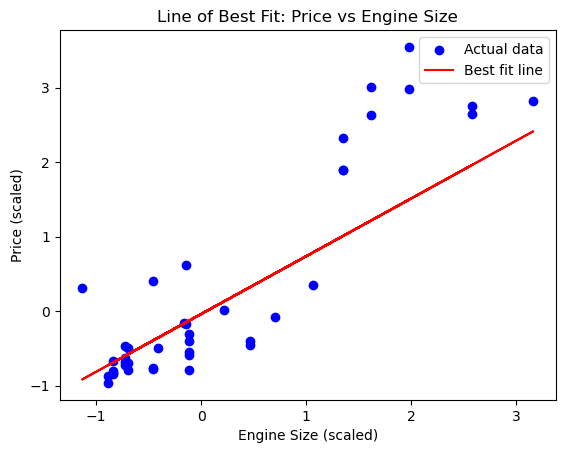

In [413]:

X_feature = X_test  # Select the column for the feature
y_pred = model.predict(X_test)

# Scatter plot of the actual data
plt.scatter(X_feature, y_test, color='blue', label='Actual data')

# Plot the line of best fit
plt.plot(X_feature, y_pred, color='red', label='Best fit line')

# Add labels, title, and legend
plt.xlabel('Engine Size (scaled)')
plt.ylabel('Price (scaled)')
plt.title('Line of Best Fit: Price vs Engine Size')
plt.legend()

plt.show()

In [415]:
#X = df2[['engine-size', 'curb-weight', 'horsepower']]  # Features
X = scaled_df[['horsepower']]  # Features

y = scaled_df['price']                                     # Target

# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [417]:
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# The coefficients
print ('Coefficients: ', model.coef_)
print ('Intercept: ',model.intercept_)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Coefficients:  [0.71435871]
Intercept:  -0.05141200897678683
Mean Squared Error: 0.733142775180434
R-squared: 0.6234317889595429


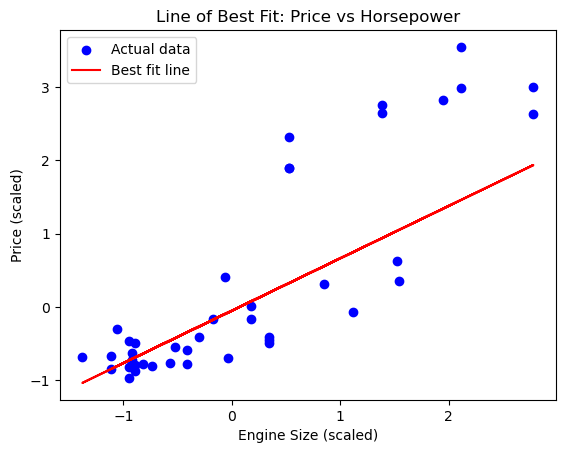

In [421]:

X_feature = X_test  # Select the column for the feature
y_pred = model.predict(X_test)

# Scatter plot of the actual data
plt.scatter(X_feature, y_test, color='blue', label='Actual data')

# Plot the line of best fit
plt.plot(X_feature, y_pred, color='red', label='Best fit line')

# Add labels, title, and legend
plt.xlabel('Engine Size (scaled)')
plt.ylabel('Price (scaled)')
plt.title('Line of Best Fit: Price vs Horsepower')
plt.legend()

plt.show()

In [423]:
#X = df2[['engine-size', 'curb-weight', 'horsepower']]  # Features
X = scaled_df[['curb-weight']]  # Features

y = scaled_df['price']                                     # Target

# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [425]:
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# The coefficients
print ('Coefficients: ', model.coef_)
print ('Intercept: ',model.intercept_)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Coefficients:  [0.74829891]
Intercept:  -0.05642680063880502
Mean Squared Error: 0.6809741239634381
R-squared: 0.6502274641352859


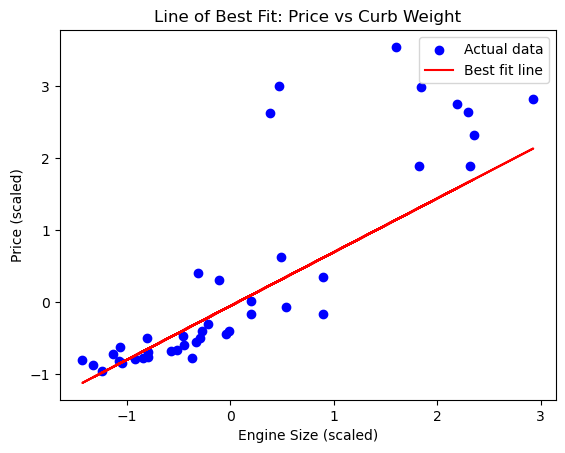

In [427]:

X_feature = X_test  # Select the column for the feature
y_pred = model.predict(X_test)

# Scatter plot of the actual data
plt.scatter(X_feature, y_test, color='blue', label='Actual data')

# Plot the line of best fit
plt.plot(X_feature, y_pred, color='red', label='Best fit line')

# Add labels, title, and legend
plt.xlabel('Engine Size (scaled)')
plt.ylabel('Price (scaled)')
plt.title('Line of Best Fit: Price vs Curb Weight')
plt.legend()

plt.show()